In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 800
temp = np.random.normal(75, 10, n)
vibration = np.random.normal(2.5, 1.0, n)
pressure = np.random.normal(30, 5, n)
rpm = np.random.normal(3000, 400, n)
run_hours = np.random.uniform(0, 5000, n)

failure_score = (0.04*(temp-75) + 0.8*(vibration-2.5) + 0.0006*run_hours
                 + np.random.normal(0, 1, n))
failure = (failure_score > 1.2).astype(int)

sensor_df = pd.DataFrame({
    "temperature_C": temp, "vibration_mm_s": vibration, "pressure_psi": pressure,
    "rpm": rpm, "run_hours": run_hours, "failure": failure
})

print("Failure rate:", sensor_df["failure"].mean().round(3))
sensor_df.head()

Failure rate: 0.57


,temperature_C,vibration_mm_s,pressure_psi,rpm,run_hours,failure
0,79.967142,3.438284,29.085518,2711.304979,4672.165194,1
1,73.617357,1.983955,36.874382,3070.728349,3445.438269,1
2,81.476885,2.596121,26.770179,2781.327966,4116.366063,1
3,90.230299,2.037725,26.004040,2891.337956,2780.953463,1
4,72.658466,2.065504,27.586282,3669.380836,3897.583507,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

X = sensor_df.drop(columns=["failure"])
y = sensor_df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
clf.fit(X_train_s, y_train)
preds = clf.predict(X_test_s)

print("Train failure rate:", y_train.mean().round(3))
print("Test failure rate:", y_test.mean().round(3))

Train failure rate: 0.57
Test failure rate: 0.57


              precision    recall  f1-score   support

     Healthy       0.79      0.80      0.80        86
     Failure       0.85      0.84      0.85       114

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.83      0.82      0.83       200



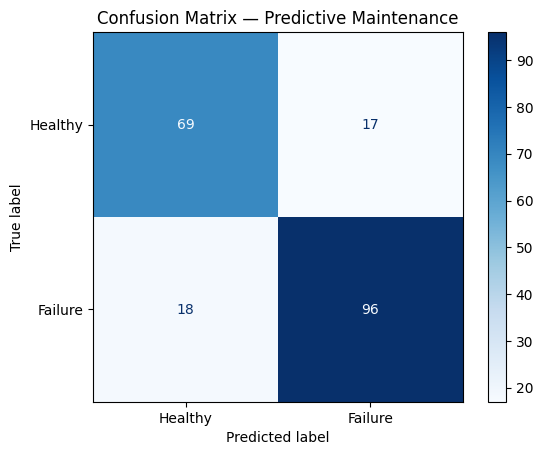

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, preds, target_names=["Healthy", "Failure"]))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Failure"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Predictive Maintenance")
plt.show()